# NEOS Portfolio Dividend Reinvestment Calculator

Tracks a portfolio of NEOS (or any monthly-paying) ETFs. For each ticker the share price and most recent dividend are pulled from Yahoo Finance, and dividends are annualized as `last_dividend * 12`.

In the `portfolio` dict, map each ticker to the number of shares you own.

**Outputs**
1. A per-ticker current snapshot (price, shares, position value, annualized dividend, annualized income) plus portfolio totals.
2. A DRIP projection: monthly compounding for each ticker over the chosen horizon, aggregated to portfolio-level yearly snapshots.
3. A stacked-area chart showing each ticker's contribution to portfolio value.
4. A detailed monthly table per ticker.

**Assumptions**
- Monthly compounding (NEOS ETFs distribute monthly).
- The annual price growth is applied uniformly per ticker (configurable per ticker if desired).
- Dividends are reinvested at the prevailing share price at the end of each month.
- No taxes or fees.

In [1]:
# --- Key inputs (edit these) ---
# Run once: pip install yfinance
import yfinance as yf

# Portfolio: map each ticker to the number of shares owned
portfolio = {
    'NEHI': 5000,
    'QQQI': 1000,
    'SPYI': 1020,
    'BTCI': 1000,
}

annual_price_growth = 0.0       # annual share price growth (applied to all tickers)
years = 8                       # holding period

MONTHS_PER_YEAR = 12

# --- Pull share price and dividend data per ticker ----------------------
holdings = {}  # ticker -> dict of computed inputs
for ticker, share_count in portfolio.items():
    tk = yf.Ticker(ticker)
    info = tk.info
    price = info.get('regularMarketPrice') or info.get('previousClose')
    if price is None:
        raise ValueError(f"Could not fetch price for {ticker}")

    dividends = tk.dividends
    if dividends.empty:
        raise ValueError(f"No dividend history found for {ticker}")
    last_dividend = float(dividends.iloc[-1])
    last_dividend_date = dividends.index[-1].date()
    annualized_dividend = last_dividend * MONTHS_PER_YEAR
    annual_yield = annualized_dividend / price

    shares = float(share_count)
    position_value = shares * price

    holdings[ticker] = {
        'name': info.get('longName') or info.get('shortName') or 'n/a',
        'price': price,
        'last_dividend': last_dividend,
        'last_dividend_date': last_dividend_date,
        'annualized_dividend': annualized_dividend,
        'annual_yield': annual_yield,
        'shares': shares,
        'position_value': position_value,
        'annualized_income': shares * annualized_dividend,
    }

# --- Per-ticker names ---------------------------------------------------
for ticker, h in holdings.items():
    print(f"{ticker} — {h['name']}")
print()

# --- Current snapshot ---------------------------------------------------
print("Current portfolio snapshot")
header = (f"{'Ticker':<8} {'Price':>10} {'Shares':>12} {'Position':>14} "
          f"{'Last Div':>10} {'Annual Div':>12} {'Yield':>8} {'Annual Income':>15}")
print(header)
print('-' * len(header))
total_position = 0.0
total_annual_income = 0.0
for ticker, h in holdings.items():
    total_position += h['position_value']
    total_annual_income += h['annualized_income']
    print(f"{ticker:<8} ${h['price']:>9,.2f} {h['shares']:>12,.2f} "
          f"${h['position_value']:>13,.0f} ${h['last_dividend']:>9.4f} "
          f"${h['annualized_dividend']:>11.4f} {h['annual_yield']:>7.2%} "
          f"${h['annualized_income']:>14,.2f}")
print('-' * len(header))
portfolio_yield = total_annual_income / total_position if total_position else 0.0
print(f"{'TOTAL':<8} {'':>10} {'':>12} ${total_position:>13,.0f} "
      f"{'':>10} {'':>12} {portfolio_yield:>7.2%} "
      f"${total_annual_income:>14,.2f}")

/Users/jslatham/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Current portfolio snapshot
Ticker        Price       Shares       Position   Last Div   Annual Div    Yield   Annual Income
------------------------------------------------------------------------------------------------
NEHI     $    35.34     5,000.00 $      176,700 $   0.9790 $    11.7480  33.24% $     58,740.00
QQQI     $    54.65     1,000.00 $       54,650 $   0.6300 $     7.5600  13.83% $      7,560.00
SPYI     $    52.71     1,020.00 $       53,764 $   0.5250 $     6.3000  11.95% $      6,426.00
BTCI     $    36.57     1,000.00 $       36,569 $   0.7980 $     9.5760  26.19% $      9,576.00
------------------------------------------------------------------------------------------------
TOTAL                            $      321,683                          25.58% $     82,302.00


In [2]:
# --- DRIP simulation per ticker, aggregated to portfolio totals --------
def simulate_drip(initial_shares, initial_price, annual_yield,
                  annual_price_growth, years):
    """Monthly DRIP simulation. Returns one row per period."""
    n = MONTHS_PER_YEAR
    total_periods = years * n
    period_growth = (1 + annual_price_growth) ** (1 / n) - 1
    period_yield = annual_yield / n

    shares = initial_shares
    price = initial_price
    rows = [{'period': 0, 'year': 0.0, 'price': price,
             'shares': shares, 'dividend': 0.0,
             'value': shares * price}]
    for p in range(1, total_periods + 1):
        price *= (1 + period_growth)
        dividend_cash = shares * price * period_yield
        shares += dividend_cash / price
        rows.append({'period': p, 'year': p / n, 'price': price,
                     'shares': shares, 'dividend': dividend_cash,
                     'value': shares * price})
    return rows

# Run the simulation per ticker
sim = {}
for ticker, h in holdings.items():
    sim[ticker] = simulate_drip(
        initial_shares=h['shares'],
        initial_price=h['price'],
        annual_yield=h['annual_yield'],
        annual_price_growth=annual_price_growth,
        years=years,
    )

n_periods = years * MONTHS_PER_YEAR + 1

# --- Portfolio-level yearly snapshot ------------------------------------
print(f"\nPortfolio DRIP projection over {years} years (monthly compounding)\n")
header = (f"{'Year':>4} {'Portfolio Value':>18} {'Annual Dividends':>18} "
          f"{'Annualized Income':>20}")
print(header)
print('-' * len(header))

cumulative_div_by_ticker = {t: 0.0 for t in holdings}
prev_year_cum_total = 0.0
for p in range(n_periods):
    # Sum dividends paid in this period across tickers
    for t in holdings:
        cumulative_div_by_ticker[t] += sim[t][p]['dividend']
    if p % MONTHS_PER_YEAR == 0:
        portfolio_value = sum(sim[t][p]['value'] for t in holdings)
        cum_div = sum(cumulative_div_by_ticker.values())
        annual_div = cum_div - prev_year_cum_total
        prev_year_cum_total = cum_div
        # Annualized income at this snapshot = current monthly dividend * 12
        annualized_income = sum(
            sim[t][p]['shares'] * holdings[t]['annualized_dividend']
            for t in holdings
        )
        year = p // MONTHS_PER_YEAR
        print(f"{year:>4} ${portfolio_value:>17,.2f} ${annual_div:>17,.2f} "
              f"${annualized_income:>19,.2f}")

# --- Per-ticker yearly final snapshot -----------------------------------
print(f"\nPer-ticker breakdown at end of year {years}\n")
header = (f"{'Ticker':<8} {'Shares':>12} {'Price':>10} {'Value':>16} "
          f"{'Total Dividends':>18} {'Annual Income':>16}")
print(header)
print('-' * len(header))
total_value = 0.0
total_total_div = 0.0
total_ann_income = 0.0
for ticker in holdings:
    final = sim[ticker][-1]
    total_div = sum(r['dividend'] for r in sim[ticker])
    annual_income = final['shares'] * holdings[ticker]['annualized_dividend']
    total_value += final['value']
    total_total_div += total_div
    total_ann_income += annual_income
    print(f"{ticker:<8} {final['shares']:>12,.2f} ${final['price']:>9,.2f} "
          f"${final['value']:>15,.2f} ${total_div:>17,.2f} "
          f"${annual_income:>15,.2f}")
print('-' * len(header))
print(f"{'TOTAL':<8} {'':>12} {'':>10} ${total_value:>15,.2f} "
      f"${total_total_div:>17,.2f} ${total_ann_income:>15,.2f}")

initial_total = sum(h['position_value'] for h in holdings.values())
total_return = (total_value / initial_total) - 1
cagr = (total_value / initial_total) ** (1 / years) - 1
print(f"\nInitial portfolio:    ${initial_total:,.2f}")
print(f"Final portfolio:      ${total_value:,.2f}")
print(f"Total dividends:      ${total_total_div:,.2f}")
print(f"Total return:         {total_return:.2%}")
print(f"CAGR:                 {cagr:.2%}")


Portfolio DRIP projection over 8 years (monthly compounding)

Year    Portfolio Value   Annual Dividends    Annualized Income
---------------------------------------------------------------
   0 $       321,683.00 $             0.00 $          82,302.00
   1 $       415,914.46 $        94,231.47 $         109,854.44
   2 $       541,998.28 $       126,083.82 $         147,356.68
   3 $       711,489.37 $       169,491.09 $         198,526.10
   4 $       940,268.79 $       228,779.43 $         268,490.58
   5 $     1,250,186.98 $       309,918.19 $         364,327.78
   6 $     1,671,335.54 $       421,148.56 $         495,811.56
   7 $     2,245,189.26 $       573,853.72 $         676,445.20
   8 $     3,028,952.81 $       783,763.55 $         924,892.06

Per-ticker breakdown at end of year 8

Ticker         Shares      Price            Value    Total Dividends    Annual Income
-------------------------------------------------------------------------------------
NEHI        68,902.40

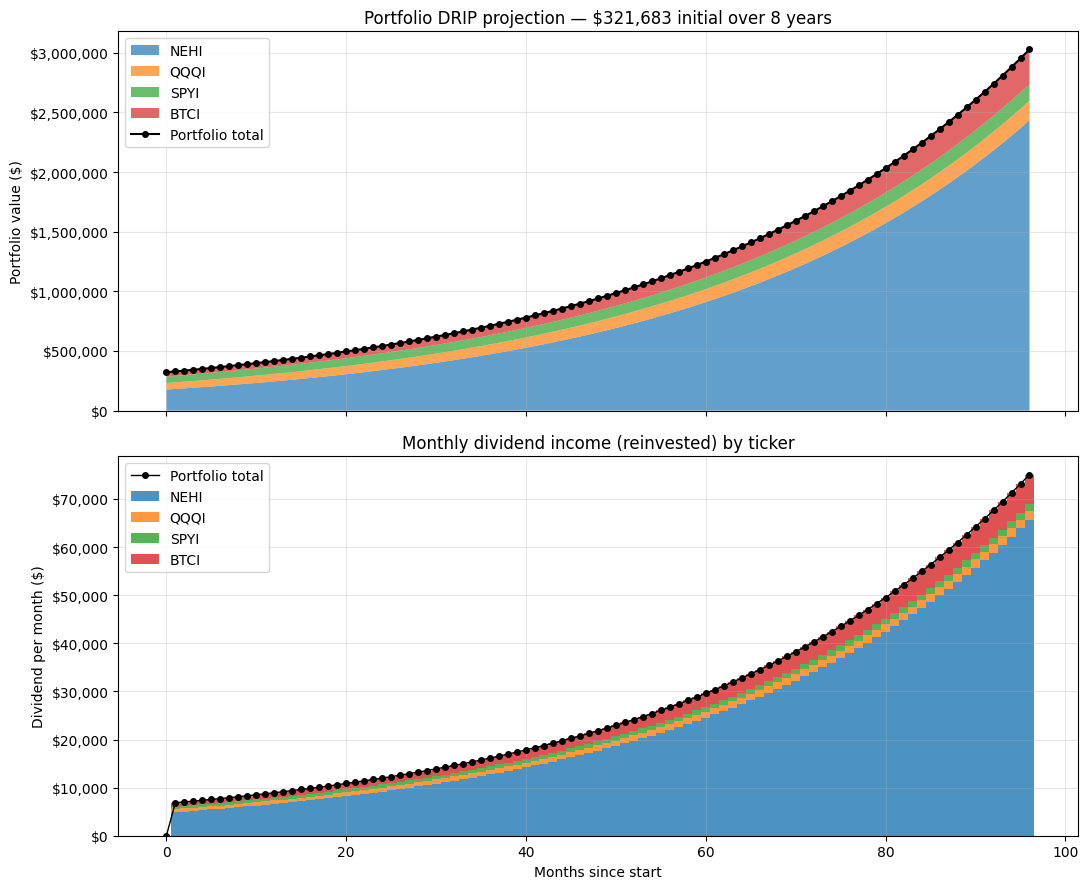

In [3]:
# --- Visualize the portfolio ---
import matplotlib.pyplot as plt

xs = list(range(n_periods))
tickers = list(holdings.keys())

# Per-ticker value over time (for stacked area)
per_ticker_value = {t: [sim[t][p]['value'] for p in xs] for t in tickers}
# Portfolio total value
portfolio_value = [sum(per_ticker_value[t][p] for t in tickers) for p in xs]
# Per-ticker dividends per period
per_ticker_div = {t: [sim[t][p]['dividend'] for p in xs] for t in tickers}
# Portfolio dividends per month
portfolio_div_per_month = [sum(per_ticker_div[t][p] for t in tickers) for p in xs]

# Color cycle for tickers
colors = plt.cm.tab10.colors

marker_size = max(2, min(6, int(400 / len(xs))))

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# Top: stacked area showing each ticker's contribution to portfolio value
ax = axes[0]
ax.stackplot(
    xs,
    *[per_ticker_value[t] for t in tickers],
    labels=tickers,
    colors=colors[:len(tickers)],
    alpha=0.7,
)
ax.plot(xs, portfolio_value, color='black', lw=1.5,
        marker='o', markersize=marker_size, label='Portfolio total')
ax.set_ylabel('Portfolio value ($)')
ax.set_title(f"Portfolio DRIP projection — ${initial_total:,.0f} initial over {years} years")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Bottom: monthly dividend income per ticker (stacked bars) + portfolio line
ax = axes[1]
bottom = [0.0] * len(xs)
for i, t in enumerate(tickers):
    ax.bar(xs, per_ticker_div[t], width=1.0, bottom=bottom,
           color=colors[i % len(colors)], alpha=0.8, label=t)
    bottom = [b + v for b, v in zip(bottom, per_ticker_div[t])]
ax.plot(xs, portfolio_div_per_month, color='black', lw=1.0,
        marker='o', markersize=marker_size, label='Portfolio total')
ax.set_xlabel('Months since start')
ax.set_ylabel('Dividend per month ($)')
ax.set_title('Monthly dividend income (reinvested) by ticker')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [7]:
# --- Detailed monthly table per ticker ---
from datetime import date
from calendar import month_abbr

today = date.today()

def period_label(period_index, start=today):
    """Calendar label for a month offset, e.g. 'Apr 2026'."""
    total_month = start.year * 12 + (start.month - 1) + period_index
    year, month_idx = divmod(total_month, 12)
    return f"{month_abbr[month_idx + 1]} {year}"

for ticker in holdings:
    print(f"\n=== {ticker} ===")
    header = (f"{'Period':>16} {'Price':>10} {'Shares':>12} "
              f"{'Dividend':>12} {'Annualized':>14} {'Value':>16}")
    print(header)
    print('-' * len(header))
    for r in sim[ticker]:
        label  = period_label(r['period'])
        price  = f"${r['price']:,.2f}"
        div    = f"${r['dividend']:,.0f}"
        ann    = f"${r['dividend'] * MONTHS_PER_YEAR:,.0f}"
        val    = f"${r['value']:,.0f}"
        print(f"{label:>16} {price:>10} {r['shares']:>12,.0f} "
              f"{div:>12} {ann:>14} {val:>16}")


=== NEHI ===
          Period      Price       Shares     Dividend     Annualized            Value
-------------------------------------------------------------------------------------
        May 2026     $35.34        5,000           $0             $0         $176,700
       June 2026     $35.34        5,139       $4,895        $58,740         $181,595
       July 2026     $35.34        5,281       $5,031        $60,367         $186,626
     August 2026     $35.34        5,427       $5,170        $62,040         $191,796
  September 2026     $35.34        5,577       $5,313        $63,758         $197,109
    October 2026     $35.34        5,732       $5,460        $65,524         $202,569
   November 2026     $35.34        5,891       $5,612        $67,340         $208,181
   December 2026     $35.34        6,054       $5,767        $69,205         $213,948
    January 2027     $35.34        6,222       $5,927        $71,122         $219,875
   February 2027     $35.34        6,394